In [1]:
import os
import pandas as pd

BASE = '/kaggle/input/datasets/paramaggarwal/fashion-product-images-small'
IMG_DIR = f'{BASE}/images'

styles = pd.read_csv(f'{BASE}/styles.csv', on_bad_lines='skip')

# Keep only products whose image file actually exists
styles['image_path'] = styles['id'].astype(str) + '.jpg'
styles['has_image'] = styles['image_path'].apply(lambda f: os.path.exists(os.path.join(IMG_DIR, f)))

print("Rows in styles.csv:", len(styles))
print("Rows with a matching image:", styles['has_image'].sum())
styles = styles[styles['has_image']].reset_index(drop=True)

styles.head()

Rows in styles.csv: 44424
Rows with a matching image: 44419


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path,has_image
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,15970.jpg,True
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,39386.jpg,True
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,59263.jpg,True
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,21379.jpg,True
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,53759.jpg,True


Top 10 categories: ['Topwear', 'Shoes', 'Bags', 'Bottomwear', 'Watches', 'Innerwear', 'Jewellery', 'Eyewear', 'Fragrance', 'Sandal']
Products kept: 36958 out of 44412


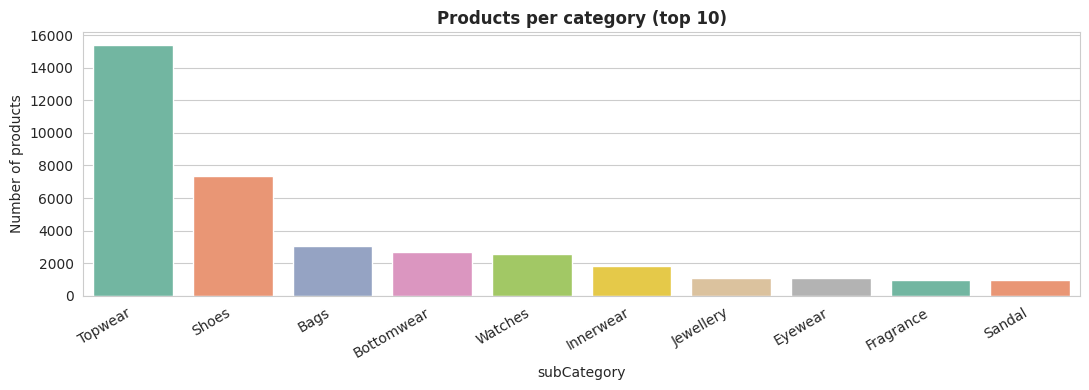

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Drop the few products with no title (needed later for the text model)
styles = styles.dropna(subset=['productDisplayName']).reset_index(drop=True)

# Keep the 10 most common subCategories
top10 = styles['subCategory'].value_counts().head(10).index.tolist()
df = styles[styles['subCategory'].isin(top10)].reset_index(drop=True)

print("Top 10 categories:", top10)
print("Products kept:", len(df), "out of", len(styles))

plt.figure(figsize=(11, 4))
counts = df['subCategory'].value_counts()
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette='Set2', legend=False)
plt.title('Products per category (top 10)', fontweight='bold')
plt.ylabel('Number of products')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

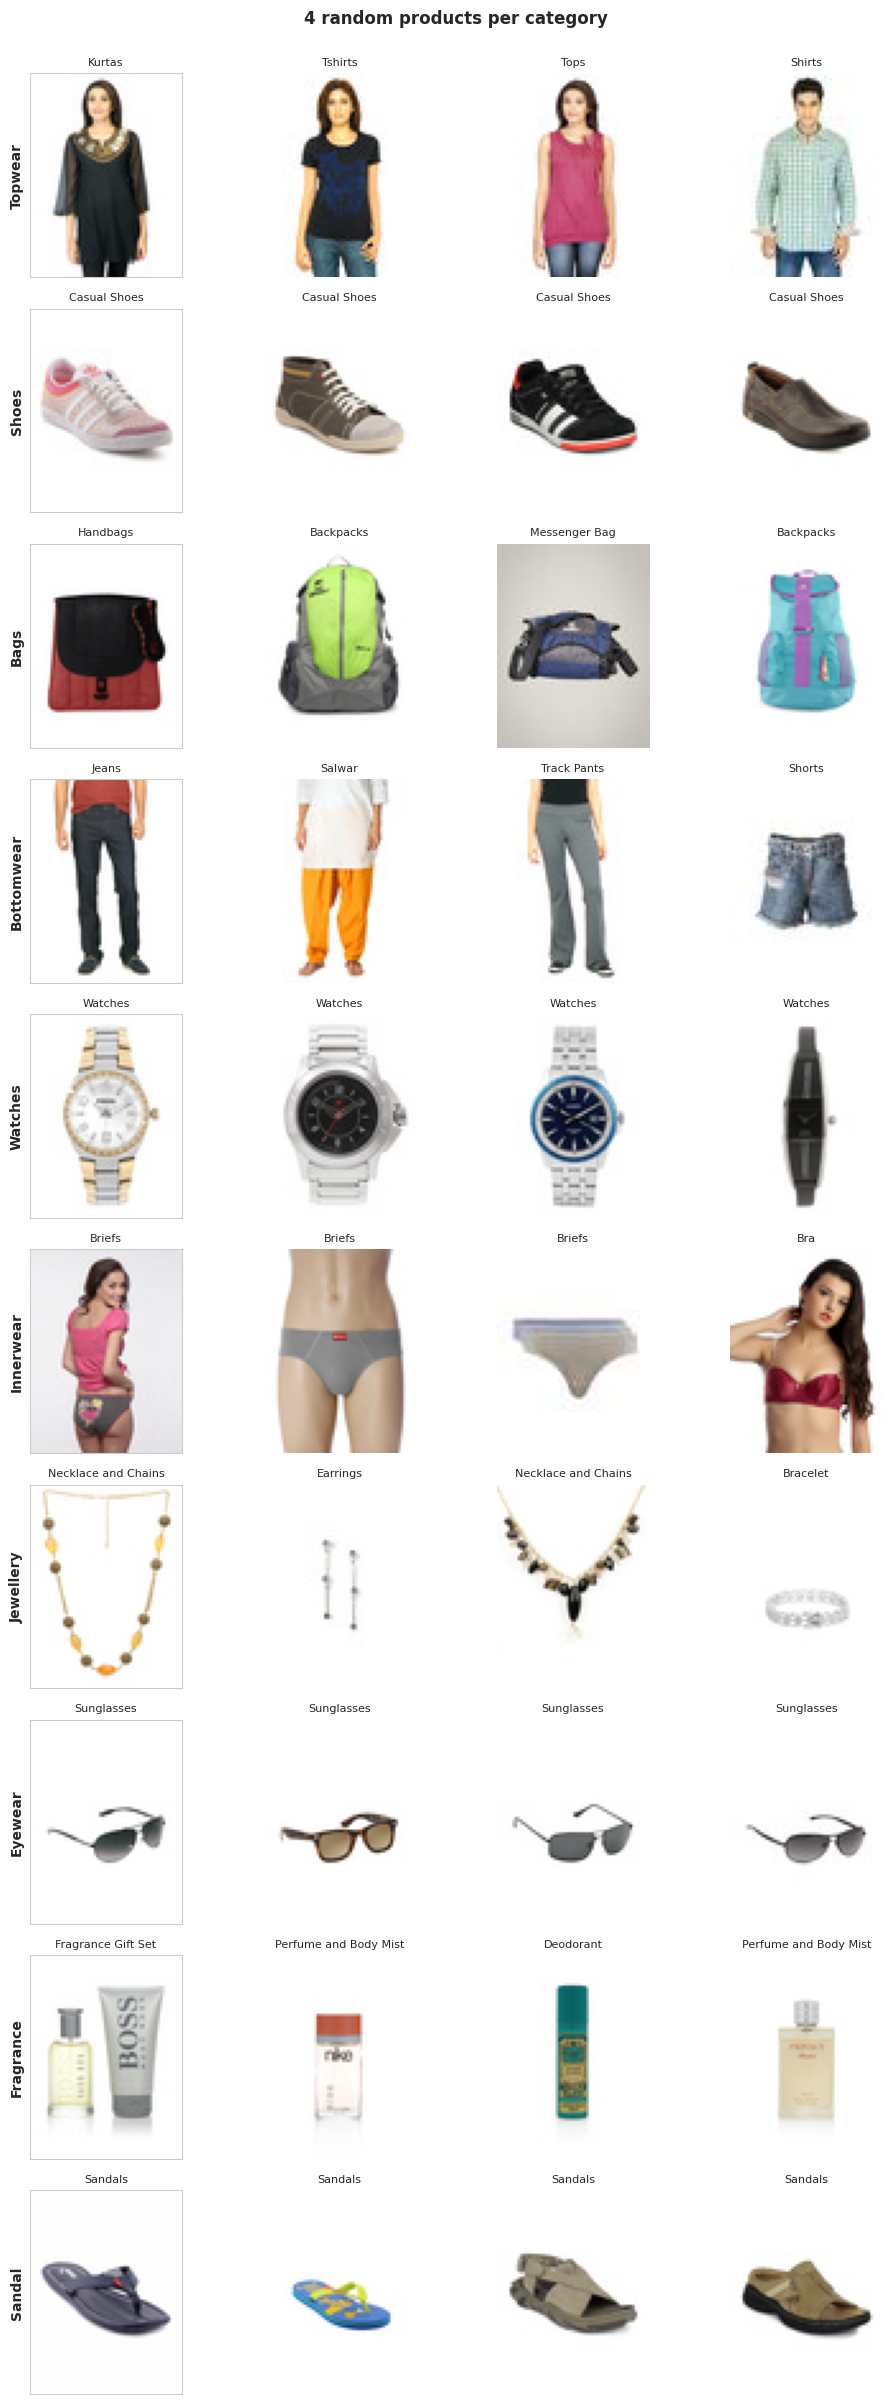

In [3]:
import os
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(10, 4, figsize=(10, 24))

for row, cat in enumerate(top10):
    samples = df[df['subCategory'] == cat].sample(4, random_state=42)
    for col, (_, item) in enumerate(samples.iterrows()):
        img = Image.open(os.path.join(IMG_DIR, item['image_path']))
        ax = axes[row, col]
        ax.imshow(img)
        ax.set_title(item['articleType'], fontsize=8)
        ax.axis('off')
    axes[row, 0].set_ylabel(cat, fontsize=10, fontweight='bold')
    axes[row, 0].axis('on')
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])

plt.suptitle('4 random products per category', fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

In [4]:
import os
from PIL import Image
from collections import Counter

sample_paths = df['image_path'].sample(500, random_state=42)
sizes, modes = Counter(), Counter()

for f in sample_paths:
    img = Image.open(os.path.join(IMG_DIR, f))
    sizes[img.size] += 1
    modes[img.mode] += 1

print("Most common image sizes (width, height):", sizes.most_common(5))
print("Color modes:", modes)

Most common image sizes (width, height): [((60, 80), 500)]
Color modes: Counter({'RGB': 496, 'L': 4})


In [5]:
import matplotlib.pyplot as plt

df['title_len'] = df['productDisplayName'].str.split().str.len()
print("Title length (words):")
print(df['title_len'].describe()[['mean', 'min', 'max']])

print("\nSample titles per category:")
for cat in top10:
    examples = df[df['subCategory'] == cat]['productDisplayName'].sample(3, random_state=1).tolist()
    print(f"\n{cat}:")
    for t in examples:
        print("   ", t)

Title length (words):
mean     5.741382
min      1.000000
max     14.000000
Name: title_len, dtype: float64

Sample titles per category:

Topwear:
    Arrow New York Men Grey Check Slim Fit Shirt
    French Connection Men Brown & Beige Shirt
    Puma Men Ferrari Logo Black Tshirts

Shoes:
    Enroute Men Leather Brown Formal Shoes
    Timberland Men Toddler Grey Casual Shoes
    Franco Leone Men Brown Shoes

Bags:
    Peperone Women Black & White Handbag
    Baggit Women Grand Hoor Red Handbag
    Be For Bag Women Combo pack Tote Bags

Bottomwear:
    Kraus Jeans Women White Leggings
    Highlander Men Brown Trousers
    Jealous 21 Women's Checkered Pink White Short

Watches:
    Q&Q Men Steel Dial Watch
    Fastrack Women Pink Dial Watch
    Timex Men Gunmetal Toned Dial Watch

Innerwear:
    Amante Women Black Briefs PGSK01
    Chromozome Men Blue Briefs
    Hanes Men Rib Chest White Innerwear Vests

Jewellery:
    Lencia Sterling Silver Pendant
    Pitaraa Golden Frame Necklace
    

## EDA findings
- 44,419 products with images; kept the top 10 subCategories → 36,958 products
- Strong class imbalance: Topwear (~15,400) vs Sandal (~960), about 16×
- All images are 60×80 px; ~1% are grayscale → convert everything to RGB
- Clothing is often shot on a model wearing a full outfit, so one image can show several categories → titles are needed to resolve ambiguity
- Titles are short (~5.7 words) and usually contain the product type directly
- Real labeling inconsistencies already visible: flip-flops and clogs filed under Sandal

In [6]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['subCategory'], random_state=42
)

# Save to disk so a Kaggle restart doesn't lose the split
train_df.to_csv('/kaggle/working/train_split.csv', index=False)
test_df.to_csv('/kaggle/working/test_split.csv', index=False)

print("Train:", len(train_df), "| Test:", len(test_df))

Train: 29566 | Test: 7392


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

tfidf = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2)
X_train_txt = tfidf.fit_transform(train_df['productDisplayName'])
X_test_txt = tfidf.transform(test_df['productDisplayName'])

text_model = LogisticRegression(max_iter=1000, class_weight='balanced')
text_model.fit(X_train_txt, train_df['subCategory'])

text_preds = text_model.predict(X_test_txt)
print(classification_report(test_df['subCategory'], text_preds))

              precision    recall  f1-score   support

        Bags       1.00      1.00      1.00       611
  Bottomwear       0.99      0.98      0.99       539
     Eyewear       1.00      1.00      1.00       214
   Fragrance       1.00      1.00      1.00       201
   Innerwear       0.99      1.00      0.99       362
   Jewellery       1.00      1.00      1.00       216
      Sandal       0.95      0.99      0.97       192
       Shoes       1.00      0.99      0.99      1469
     Topwear       1.00      1.00      1.00      3080
     Watches       1.00      1.00      1.00       508

    accuracy                           1.00      7392
   macro avg       0.99      1.00      0.99      7392
weighted avg       1.00      1.00      1.00      7392



In [8]:
import pandas as pd
pd.set_option('display.max_colwidth', 80)

errors = test_df.copy()
errors['text_pred'] = text_preds
errors = errors[errors['subCategory'] != errors['text_pred']]

print("Number of disagreements:", len(errors), "out of", len(test_df))
errors[['id', 'productDisplayName', 'articleType', 'subCategory', 'text_pred']]

Number of disagreements: 32 out of 7392


,id,productDisplayName,articleType,subCategory,text_pred
7156,10715,Nike Women Training sports bra Black Tops,Tops,Topwear,Innerwear
20310,5408,Quechua Wayta Jr Blue,Sports Shoes,Shoes,Topwear
8809,40009,Park Avenue Men Black & Green Frame Sunglasses,Tunics,Topwear,Eyewear
14274,51245,Clarks Women Purple & Brown Surf Legend Sandals,Flats,Shoes,Sandal
16911,34071,Clarks Women Saturn Whizz Leather Black Sandals,Flats,Shoes,Sandal
25006,10717,Nike Women Trainng sports bra Purple Tops,Tops,Topwear,Innerwear
5104,6391,Lotto Women Sofia Pink Black Floater,Flats,Shoes,Sandal
13854,5018,Levis Kids Boy's Aldon White Kidswear,Shorts,Bottomwear,Topwear
32541,1618,Reebok Men United Runner White,Sports Shoes,Shoes,Topwear
30796,42971,Amante Pink & Blue Swimwear,Swimwear,Bottomwear,Innerwear


In [9]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

BASE = '/kaggle/input/datasets/paramaggarwal/fashion-product-images-small'
IMG_DIR = f'{BASE}/images'
IMG_SIZE = 96
BATCH = 64

print("GPU available:", tf.config.list_physical_devices('GPU'))

# Reload the saved split (safe even if Kaggle restarted)
train_df = pd.read_csv('/kaggle/working/train_split.csv')
test_df = pd.read_csv('/kaggle/working/test_split.csv')

# Category name -> number (0-9)
class_names = sorted(train_df['subCategory'].unique())
class_to_idx = {c: i for i, c in enumerate(class_names)}
print("Classes:", class_names)

# Carve a validation set out of TRAIN only (test stays untouched until the end)
train_part, val_part = train_test_split(
    train_df, test_size=0.1, stratify=train_df['subCategory'], random_state=42
)

def make_dataset(frame, shuffle):
    paths = (IMG_DIR + '/' + frame['image_path']).values
    labels = frame['subCategory'].map(class_to_idx).values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(frame), seed=42)

    def load(path, label):
        img = tf.io.read_file(path)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)  # forces RGB
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        return img, label

    return ds.map(load, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_part, shuffle=True)
val_ds = make_dataset(val_part, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)   # order must match test_df

print("Train:", len(train_part), "| Val:", len(val_part), "| Test:", len(test_df))

images, labels = next(iter(train_ds))
print("One batch:", images.shape, labels.shape)

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Classes: ['Bags', 'Bottomwear', 'Eyewear', 'Fragrance', 'Innerwear', 'Jewellery', 'Sandal', 'Shoes', 'Topwear', 'Watches']


I0000 00:00:1791102508.845678      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791102508.849084      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Train: 26609 | Val: 2957 | Test: 7392
One batch: (64, 96, 96, 3) (64,)


In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.utils.class_weight import compute_class_weight

# Pretrained base: already knows edges, textures and shapes from ImageNet
base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base.trainable = False   # freeze it: only our new layers learn at first

augment = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomZoom(0.1),
])

image_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    augment,
    layers.Rescaling(1./127.5, offset=-1),   # 0-255 -> -1..1, the range MobileNetV2 expects
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

image_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
image_model.summary()

# Class weights to handle the 16x imbalance (Topwear vs Sandal)
y_train_idx = train_part['subCategory'].map(class_to_idx).values
weights = compute_class_weight('balanced', classes=np.arange(len(class_names)), y=y_train_idx)
class_weight = dict(enumerate(weights))
print("Class weights:", {class_names[i]: round(w, 2) for i, w in class_weight.items()})

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Class weights: {'Bags': np.float64(1.21), 'Bottomwear': np.float64(1.37), 'Eyewear': np.float64(3.44), 'Fragrance': np.float64(3.68), 'Innerwear': np.float64(2.05), 'Jewellery': np.float64(3.42), 'Sandal': np.float64(3.83), 'Shoes': np.float64(0.5), 'Topwear': np.float64(0.24), 'Watches': np.float64(1.45)}


In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

history = image_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight,
    callbacks=[early_stop]
)

Epoch 1/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 63s 134ms/step - accuracy: 0.8754 - loss: 0.3682 - val_accuracy: 0.9489 - val_loss: 0.1509
Epoch 2/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9378 - loss: 0.1538 - val_accuracy: 0.9571 - val_loss: 0.1229
Epoch 3/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9471 - loss: 0.1247 - val_accuracy: 0.9486 - val_loss: 0.1378
Epoch 4/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9529 - loss: 0.1060 - val_accuracy: 0.9554 - val_loss: 0.1258
Epoch 5/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9564 - loss: 0.0944 - val_accuracy: 0.9679 - val_loss: 0.0940
Epoch 6/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9568 - loss: 0.0940 - val_accuracy: 0.9682 - val_loss: 0.0991
Epoch 7/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9596 - loss: 0.0865 - val_accuracy: 0.9652 - val_loss: 0.1027
Epoch 8/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9621 - loss: 0.0795 -

In [12]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

base.trainable = True
for layer in base.layers[:-30]:      # keep everything except the last 30 layers frozen
    layer.trainable = False
for layer in base.layers:            # keep BatchNorm layers frozen (standard practice when fine-tuning)
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

image_model.compile(optimizer=Adam(learning_rate=1e-5),   # 100x smaller than before
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

history_ft = image_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weight,
    callbacks=[early_stop]
)

Epoch 1/8
416/416 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.9661 - loss: 0.0768 - val_accuracy: 0.9706 - val_loss: 0.0887
Epoch 2/8
416/416 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.9713 - loss: 0.0624 - val_accuracy: 0.9713 - val_loss: 0.0839
Epoch 3/8
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9732 - loss: 0.0553 - val_accuracy: 0.9675 - val_loss: 0.0928
Epoch 4/8
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9793 - loss: 0.0434 - val_accuracy: 0.9685 - val_loss: 0.0938
Epoch 5/8
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9794 - loss: 0.0404 - val_accuracy: 0.9807 - val_loss: 0.0628
Epoch 6/8
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9811 - loss: 0.0367 - val_accuracy: 0.9794 - val_loss: 0.0696
Epoch 7/8
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9844 - loss: 0.0323 - val_accuracy: 0.9797 - val_loss: 0.0631
Epoch 8/8
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9854 - loss: 0.0293 - val_accu

In [13]:
from sklearn.metrics import classification_report

img_probs = image_model.predict(test_ds)
img_preds_idx = img_probs.argmax(axis=1)
img_preds = [class_names[i] for i in img_preds_idx]

print(classification_report(test_df['subCategory'], img_preds))


116/116 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step
              precision    recall  f1-score   support

        Bags       0.98      1.00      0.99       611
  Bottomwear       0.99      0.99      0.99       539
     Eyewear       1.00      1.00      1.00       214
   Fragrance       0.97      0.98      0.97       201
   Innerwear       0.95      0.97      0.96       362
   Jewellery       0.97      0.98      0.97       216
      Sandal       0.81      0.89      0.85       192
       Shoes       0.99      0.97      0.98      1469
     Topwear       1.00      0.99      0.99      3080
     Watches       1.00      0.99      1.00       508

    accuracy                           0.98      7392
   macro avg       0.96      0.98      0.97      7392
weighted avg       0.98      0.98      0.98      7392



## Image model findings
- MobileNetV2 transfer learning (frozen base, then fine-tuned the top 30 layers) reached ~98% test accuracy
- Weakest class: Sandal (F1 0.85). Partly genuine visual similarity to shoes at 60×80 resolution, and partly
  because the catalog's own inconsistent labels (sandals filed under Shoes) were used as training targets
- Innerwear (F1 0.96) is affected by photos showing full outfits on models

In [14]:
import pandas as pd

image_model.save('/kaggle/working/image_model.keras')

# Recompute text predictions on the reloaded test_df to be safe
text_preds = text_model.predict(tfidf.transform(test_df['productDisplayName']))

results = test_df[['id', 'productDisplayName', 'articleType', 'subCategory', 'image_path']].copy()
results['text_pred'] = text_preds
results['img_pred'] = img_preds
results['img_conf'] = img_probs.max(axis=1)   # how confident the image model was

results.to_csv('/kaggle/working/predictions.csv', index=False)
print("Saved", len(results), "rows")
results.head()

Saved 7392 rows


,id,productDisplayName,articleType,subCategory,image_path,text_pred,img_pred,img_conf
0,5214,Disney Kids Boy's White Mickey Abhoy Red Set of 2 Kidswear,Tshirts,Topwear,5214.jpg,Topwear,Topwear,0.999673
1,7816,Puma Women Corsica Mid L Shine Black Grey Shoe,Casual Shoes,Shoes,7816.jpg,Shoes,Shoes,0.999999
2,53149,Catwalk Women Red Heels,Heels,Shoes,53149.jpg,Shoes,Shoes,0.999992
3,49967,Hanes Men White Pack of Two Premium Bikini Briefs,Briefs,Innerwear,49967.jpg,Innerwear,Innerwear,0.973575
4,48786,Lucera Women Silver Pendant,Pendant,Jewellery,48786.jpg,Jewellery,Jewellery,0.816410


In [15]:
import pandas as pd

results = pd.read_csv('/kaggle/working/predictions.csv')

def audit(row):
    label = row['subCategory']
    text = row['text_pred']
    img = row['img_pred']

    if text == label and img == label:
        return 'OK'                          # everyone agrees
    if text == img and text != label:
        return 'LIKELY MISLABEL'             # both models agree with each other, against the label
    if text == label or img == label:
        return 'ONE MODEL DISAGREES'         # one model backs the label, the other doesn't
    return 'ALL DIFFERENT'                   # label, text and image all say different things

results['audit'] = results.apply(audit, axis=1)
print(results['audit'].value_counts())

audit
OK                     7243
ONE MODEL DISAGREES     139
LIKELY MISLABEL           6
ALL DIFFERENT             4
Name: count, dtype: int64


Likely mislabels: 6


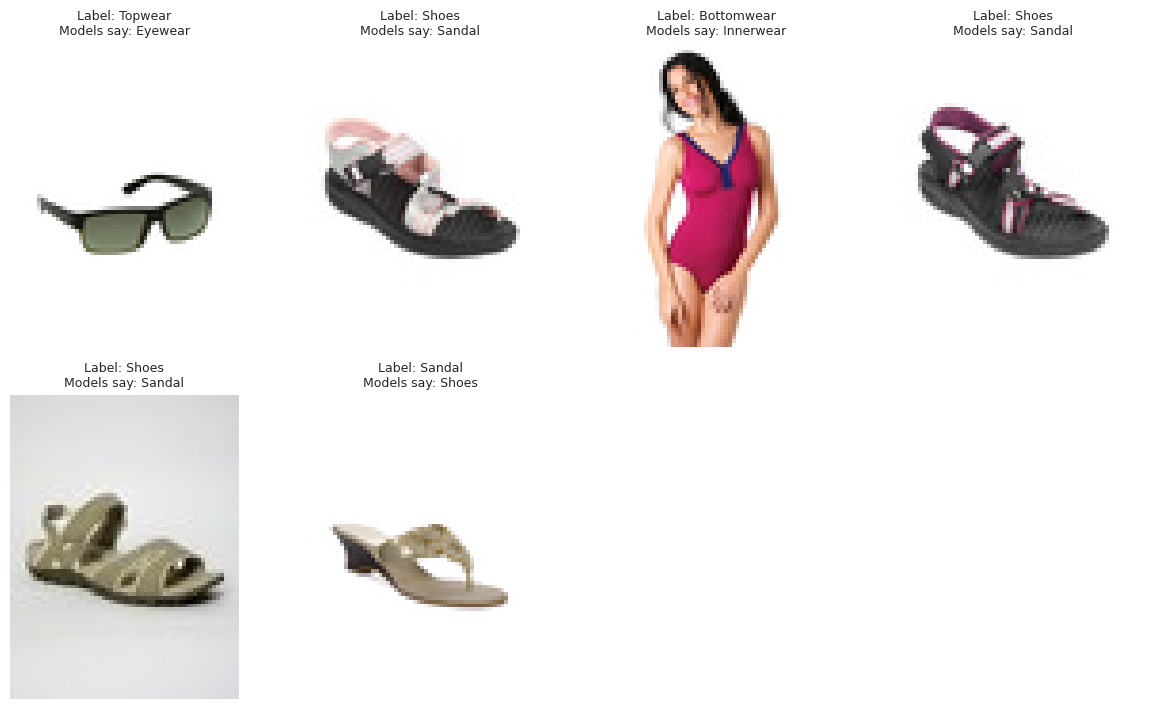

,id,productDisplayName,articleType,subCategory,text_pred,img_pred,img_conf
0,40009,Park Avenue Men Black & Green Frame Sunglasses,Tunics,Topwear,Eyewear,Eyewear,1.000000
1,6391,Lotto Women Sofia Pink Black Floater,Flats,Shoes,Sandal,Sandal,0.971852
2,42971,Amante Pink & Blue Swimwear,Swimwear,Bottomwear,Innerwear,Innerwear,0.967351
3,6390,Lotto Women Sofia Purple Black Floater,Flats,Shoes,Sandal,Sandal,0.971484
4,5351,Quechua Arpenaz Sandal 50 L Beige,Sports Shoes,Shoes,Sandal,Sandal,0.989112
5,26180,Rocia Women Gold Casual Sandals,Sandals,Sandal,Shoes,Shoes,0.992987


In [16]:
import os
import matplotlib.pyplot as plt
from PIL import Image

IMG_DIR = '/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images'

flagged = results[results['audit'] == 'LIKELY MISLABEL'].reset_index(drop=True)
print("Likely mislabels:", len(flagged))

n = min(len(flagged), 12)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12, 3.6 * rows))
axes = axes.flatten()

for i in range(n):
    item = flagged.iloc[i]
    img = Image.open(os.path.join(IMG_DIR, item['image_path']))
    axes[i].imshow(img)
    axes[i].set_title(f"Label: {item['subCategory']}\nModels say: {item['text_pred']}", fontsize=9)
    axes[i].axis('off')
for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

flagged[['id', 'productDisplayName', 'articleType', 'subCategory', 'text_pred', 'img_pred', 'img_conf']]

## Mislabel detection findings
- 98.0% of test listings: label, text model and image model all agree
- 6 listings flagged as LIKELY MISLABEL (both models agree against the seller label):
  - 4 genuine: sunglasses filed as Topwear, and 3 sandals/floaters filed as Shoes
  - 1 grey area: swimwear filed as Bottomwear (no swimwear category exists)
  - 1 false alarm: a correctly labelled sandal, caused by inconsistent training labels for that brand
- The two-model rule is conservative: high precision, lower recall. Many of the text model's sandal
  findings fall into "one model disagrees" instead, which suits a human review queue

In [23]:
import numpy as np
import pandas as pd

classes = sorted(results['subCategory'].unique())

# Realistic confusions: swap to a look-alike category where one exists
look_alikes = {'Shoes': 'Sandal', 'Sandal': 'Shoes',
               'Topwear': 'Innerwear', 'Innerwear': 'Topwear',
               'Bottomwear': 'Topwear', 'Watches': 'Jewellery', 'Jewellery': 'Watches'}

def run_experiment(mode, rate=0.05, seed=42):
    rng = np.random.default_rng(seed)
    data = results.copy()
    data['is_corrupted'] = False

    idx = rng.choice(len(data), size=int(rate * len(data)), replace=False)
    for i in idx:
        original = data.at[i, 'subCategory']
        if mode == 'realistic' and original in look_alikes:
            new_label = look_alikes[original]
        else:
            new_label = rng.choice([c for c in classes if c != original])
        data.at[i, 'subCategory'] = new_label
        data.at[i, 'is_corrupted'] = True

    data['audit'] = data.apply(audit, axis=1)

    flagged = data['audit'] == 'LIKELY MISLABEL'
    any_flag = data['audit'] != 'OK'
    corrupted = data['is_corrupted']

    return {
        'mode': mode,
        'corrupted': int(corrupted.sum()),
        'recall (likely mislabel)': (flagged & corrupted).sum() / corrupted.sum(),
        'precision (likely mislabel)': (flagged & corrupted).sum() / flagged.sum(),
        'recall (any flag)': (any_flag & corrupted).sum() / corrupted.sum(),
    }

experiment = pd.DataFrame([run_experiment('random'), run_experiment('realistic')])
experiment.round(3)

,mode,corrupted,recall (likely mislabel),precision (likely mislabel),recall (any flag)
0,random,369,0.981,0.986,1.000
1,realistic,369,0.978,0.986,0.997


## Injected-mislabel experiment
- Deliberately corrupted 5% of test labels (369 products) and measured detection:
  - Random wrong labels: 98.1% recall, 98.6% precision (high-confidence bucket); 100% landed in some flagged bucket
  - Realistic look-alike errors (e.g. shoes ↔ sandal): 97.8% recall, 98.6% precision; 99.7% flagged
- Precision is conservative: the 6 real mislabels found earlier count as false alarms here
- Limitation: injected errors are random one-offs. Systematic catalog conventions (e.g. sandals
  consistently filed as Shoes) are learned by the models and are harder to detect automatically;
  these surface in the "one model disagrees" review queue instead

In [24]:
import os
import json
import joblib

os.makedirs('/kaggle/working/app_artifacts', exist_ok=True)

# Text model + its vocabulary
joblib.dump(tfidf, '/kaggle/working/app_artifacts/tfidf.joblib')
joblib.dump(text_model, '/kaggle/working/app_artifacts/text_model.joblib')

# Class order (the image model outputs numbers in this exact order)
with open('/kaggle/working/app_artifacts/class_names.json', 'w') as f:
    json.dump(class_names, f)

# Image model (already saved in Cell 15) + predictions with audit buckets
import shutil
shutil.copy('/kaggle/working/image_model.keras', '/kaggle/working/app_artifacts/image_model.keras')
results.to_csv('/kaggle/working/app_artifacts/predictions_with_audit.csv', index=False)

print(os.listdir('/kaggle/working/app_artifacts'))

['tfidf.joblib', 'predictions_with_audit.csv', 'class_names.json', 'text_model.joblib', 'image_model.keras']


In [25]:
import os
import shutil
import sklearn
import tensorflow as tf
import keras

# 1) Versions: your laptop must use matching versions or the saved models may not load
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("scikit-learn:", sklearn.__version__)

# 2) Copy images for every flagged product + 300 random OK ones (for the app's bulk-audit page)
IMG_DIR = '/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images'
out_img_dir = '/kaggle/working/app_artifacts/images'
os.makedirs(out_img_dir, exist_ok=True)

flagged_rows = results[results['audit'] != 'OK']
ok_sample = results[results['audit'] == 'OK'].sample(300, random_state=42)
to_copy = pd.concat([flagged_rows, ok_sample])

for f in to_copy['image_path']:
    shutil.copy(os.path.join(IMG_DIR, f), out_img_dir)
print("Images copied:", len(os.listdir(out_img_dir)))

# 3) Zip the whole folder into a single download
shutil.make_archive('/kaggle/working/app_artifacts', 'zip', '/kaggle/working/app_artifacts')
print("Zip size (MB):", round(os.path.getsize('/kaggle/working/app_artifacts.zip') / 1e6, 1))

TensorFlow: 2.20.0
Keras: 3.13.2
scikit-learn: 1.6.1
Images copied: 449
Zip size (MB): 23.8
